In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
df = pd.read_csv('../data/raw/books.csv')

# Dataset Inspection

In [30]:
df.shape

(6810, 12)

In [31]:
df.head()

,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6810 entries, 0 to 6809
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   isbn13          6810 non-null   int64  
 1   isbn10          6810 non-null   str    
 2   title           6810 non-null   str    
 3   subtitle        2381 non-null   str    
 4   authors         6738 non-null   str    
 5   categories      6711 non-null   str    
 6   thumbnail       6481 non-null   str    
 7   description     6548 non-null   str    
 8   published_year  6804 non-null   float64
 9   average_rating  6767 non-null   float64
 10  num_pages       6767 non-null   float64
 11  ratings_count   6767 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 4.3 MB


In [33]:
df.isnull().sum()

isbn13               0
isbn10               0
title                0
subtitle          4429
authors             72
categories          99
thumbnail          329
description        262
published_year       6
average_rating      43
num_pages           43
ratings_count       43
dtype: int64

# Check for Duplicates

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df['title'].duplicated().sum()

np.int64(412)

In [48]:
duplicate_title_author = df[df.duplicated(subset=['title', 'authors'], keep=False)]

duplicate_title_author[['title', 'authors']].sort_values(['title', 'authors'])

,title,authors
539,"""Surely You're Joking, Mr. Feynman!""",Richard Phillips Feynman;Ralph Leighton
2398,"""Surely You're Joking, Mr. Feynman!""",Richard Phillips Feynman;Ralph Leighton
4635,"20,000 Leagues Under the Sea",Jules Verne
5407,"20,000 Leagues Under the Sea",Jules Verne
3400,A Brief History of Time,Stephen Hawking
...,...,...
2084,White Teeth,Zadie Smith
2453,Wuthering Heights,Emily Bronte;Emily Brontë
3064,Wuthering Heights,Emily Bronte;Emily Brontë
206,Zen and the Art of Motorcycle Maintenance,Robert M. Pirsig


There are now exact duplicate books. The duplicate books are different editions so there is no need to remove them from the database. 

# Distribution Analysis

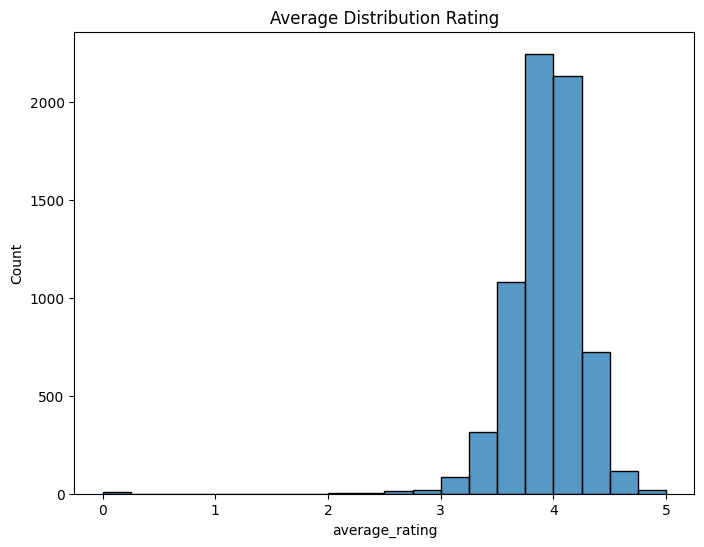

In [60]:
plt.figure(figsize=(8,6))
sns.histplot(df['average_rating'], bins=20)
plt.title("Average Distribution Rating")
plt.show()

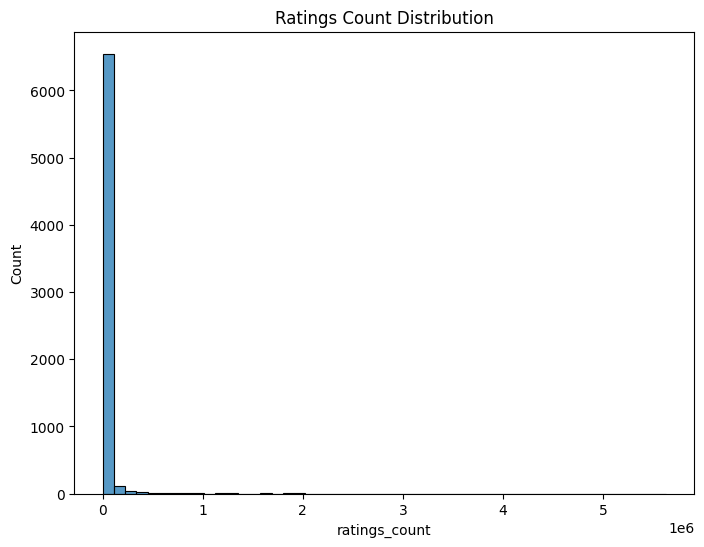

In [61]:
plt.figure(figsize=(8,6))
sns.histplot(df['ratings_count'], bins=50)
plt.title("Ratings Count Distribution")
plt.show()

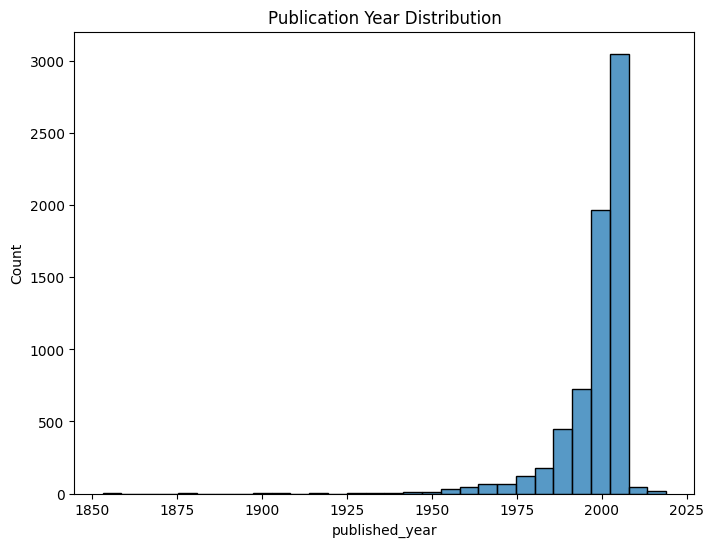

In [59]:
plt.figure(figsize=(8,6))
sns.histplot(df['published_year'], bins=30)
plt.title("Publication Year Distribution")
plt.show()

In [62]:
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

subtitle          65.036711
thumbnail          4.831131
description        3.847283
categories         1.453744
authors            1.057269
average_rating     0.631424
num_pages          0.631424
ratings_count      0.631424
published_year     0.088106
isbn13             0.000000
isbn10             0.000000
title              0.000000
dtype: float64

In [63]:
df['categories'].value_counts().head(20)

categories
Fiction                      2588
Juvenile Fiction              538
Biography & Autobiography     401
History                       264
Literary Criticism            166
Philosophy                    160
Comics & Graphic Novels       159
Religion                      137
Drama                         132
Juvenile Nonfiction           116
Poetry                         79
Literary Collections           71
Science                        71
Business & Economics           67
Social Science                 60
Performing Arts                50
Cooking                        47
Art                            46
Body, Mind & Spirit            44
Psychology                     43
Name: count, dtype: int64

In [64]:
df['authors'].value_counts().head(20)

authors
Agatha Christie                37
Stephen King                   36
William Shakespeare            35
John Ronald Reuel Tolkien      26
Virginia Woolf                 23
Sandra Brown                   23
Orson Scott Card               21
Janet Evanovich                20
Piers Anthony                  19
Terry Pratchett                17
Terry Brooks                   17
Mercedes Lackey                17
Margaret Weis;Tracy Hickman    16
Roald Dahl                     16
Jane Austen                    16
C. S. Lewis                    15
Bill Bryson                    15
John Grisham                   15
Charles Dickens                15
Gordon Korman                  15
Name: count, dtype: int64

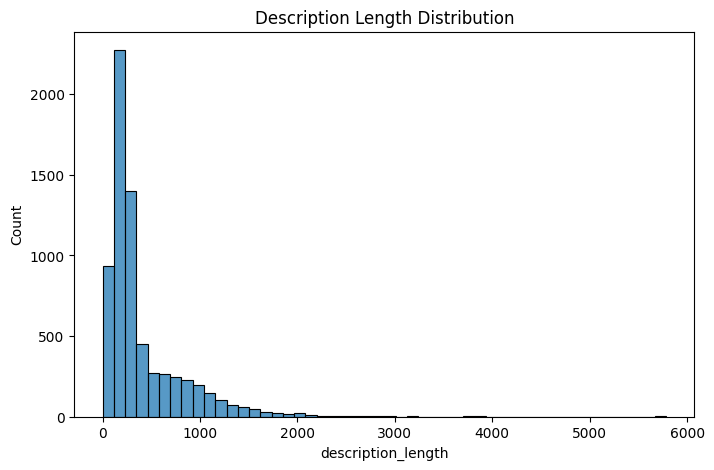

In [66]:
df['description_length'] = df['description'].fillna('').apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df['description_length'], bins=50)
plt.title("Description Length Distribution")
plt.show()